In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
df=pd.read_csv('recipe.csv')

In [4]:
df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [5]:
df.columns

Index(['recipe', 'calories', 'carbohydrate', 'sugar', 'protein', 'category',
       'servings', 'high_traffic'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


In [7]:
df.describe()

,recipe,calories,carbohydrate,sugar,protein
count,947.000000,895.000000,895.000000,895.000000,895.000000
mean,474.000000,435.939196,35.069676,9.046547,24.149296
std,273.519652,453.020997,43.949032,14.679176,36.369739
min,1.000000,0.140000,0.030000,0.010000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000
50%,474.000000,288.550000,21.480000,4.550000,10.800000
75%,710.500000,597.650000,44.965000,9.800000,30.200000
max,947.000000,3633.160000,530.420000,148.750000,363.360000


In [8]:
print(df.isnull().sum())

recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64


In [9]:
num_cols = ['calories', 'carbohydrate', 'sugar', 'protein']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
print(df.isnull().sum())

recipe            0
calories          0
carbohydrate      0
sugar             0
protein           0
category          0
servings          0
high_traffic    373
dtype: int64


In [11]:
df['high_traffic'] = df['high_traffic'].fillna('Low')

In [12]:
print(df.isnull().sum())

recipe          0
calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
high_traffic    0
dtype: int64


# Calories Distribution

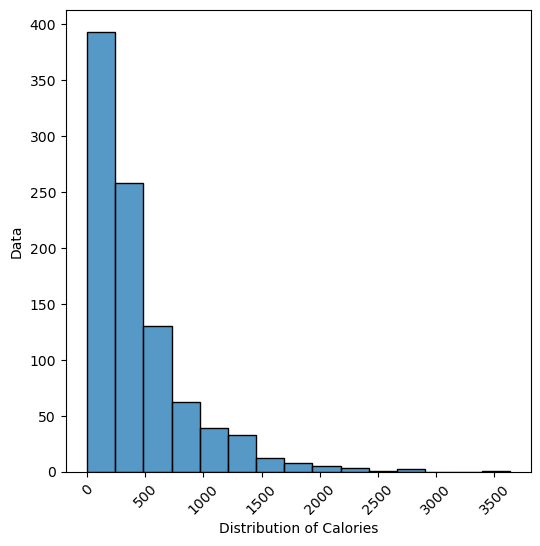

In [13]:
plt.figure(figsize=(6,6))
sns.histplot(df['calories'],bins=15)
plt.xlabel('Distribution of Calories')
plt.ylabel('Data')
plt.xticks(rotation=45)
plt.show()

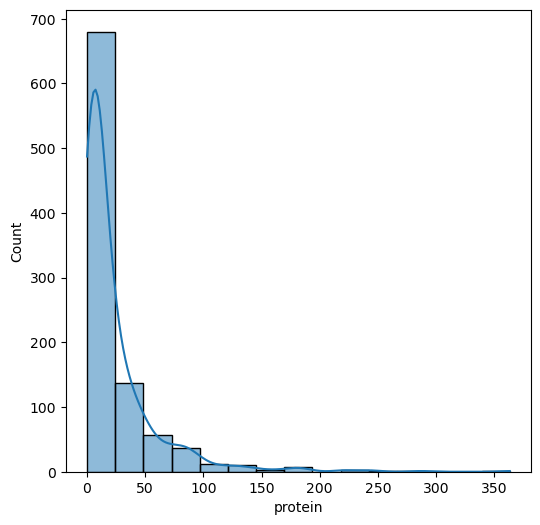

In [14]:
plt.figure(figsize=(6,6))
sns.histplot(df['protein'],bins=15,kde=True)
plt.show()

In [15]:
#avg calories by category
df1=df.groupby('category')['calories'].sum().sort_values(ascending=False)
df1

category
Chicken Breast    51946.02
Pork              49142.74
Meat              44698.25
Lunch/Snacks      41285.43
Chicken           40547.26
One Dish Meal     39953.23
Potato            36723.44
Breakfast         35179.28
Dessert           28789.26
Vegetable         20553.91
Beverages         16351.36
Name: calories, dtype: float64

In [16]:
df1.mean()

np.float64(36833.652727272725)

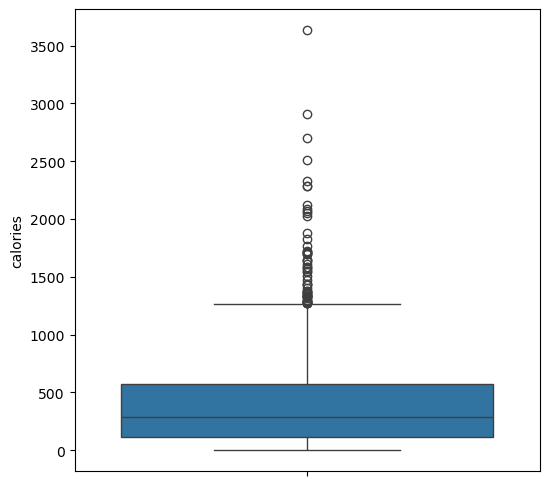

In [17]:
plt.figure(figsize=(6,6))
sns.boxplot(df['calories'])
plt.show()

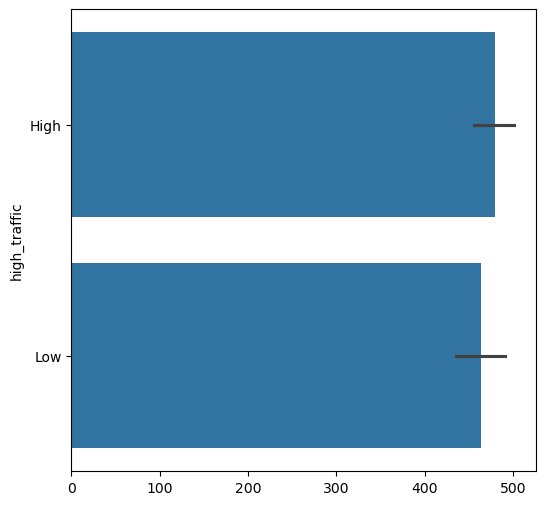

In [18]:
plt.figure(figsize=(6,6))
sns.barplot(df['high_traffic'])
plt.show()

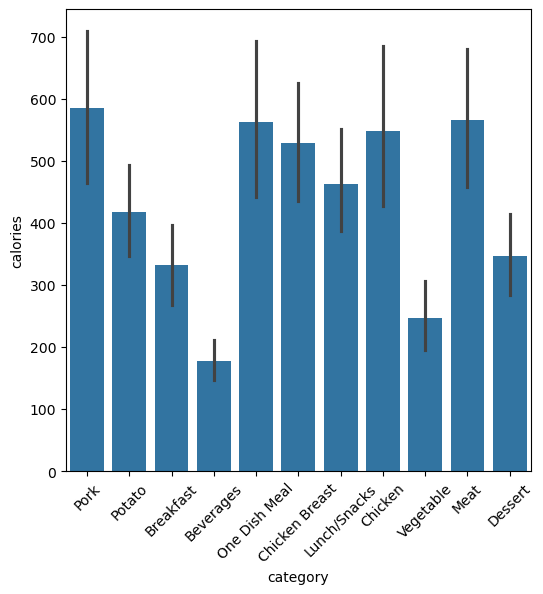

In [21]:
# bar plot for category vs avg calorie
plt.figure(figsize=(6,6))
sns.barplot(x='category',y='calories',data=df)
plt.xticks(rotation=45)
plt.show()

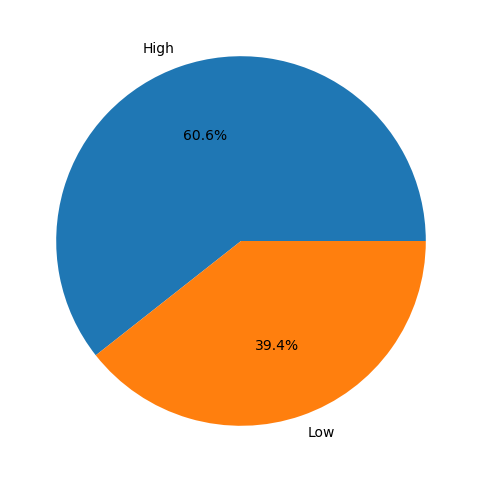

In [26]:
#pie chart of hightraffic
pie1=df['high_traffic'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(pie1,labels=pie1.index,autopct='%1.1f%%')
plt.show()

In [27]:
df.columns

Index(['recipe', 'calories', 'carbohydrate', 'sugar', 'protein', 'category',
       'servings', 'high_traffic'],
      dtype='object')

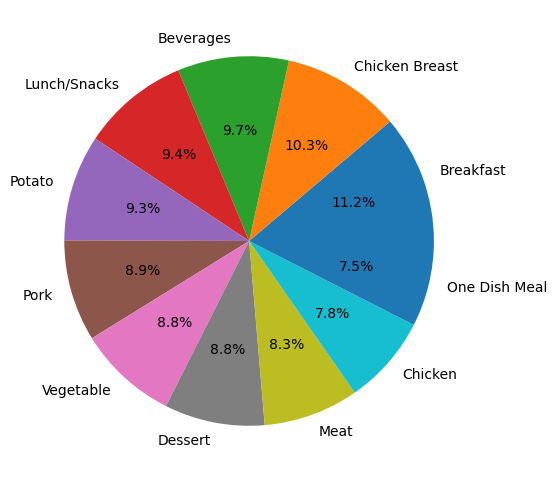

In [63]:
pie2=df['category'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(pie2,labels=pie2.index,autopct='%1.1f%%')
plt.show()

In [64]:
df4=df.groupby('protein')['calories'].sum().sort_values(ascending=False)

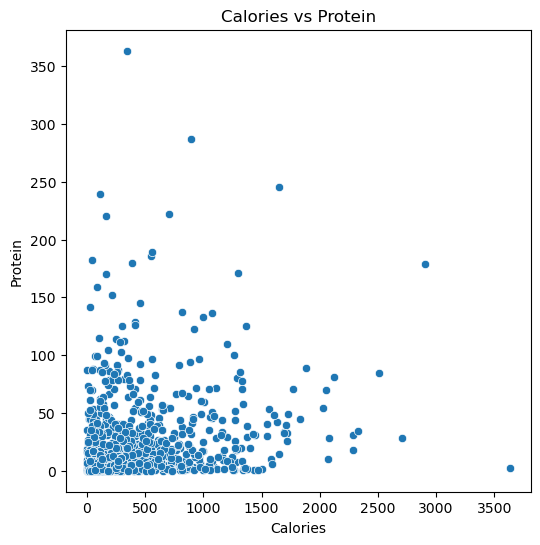

In [65]:
plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x='calories', y='protein')
plt.title("Calories vs Protein")
plt.xlabel("Calories")
plt.ylabel("Protein")
plt.show()

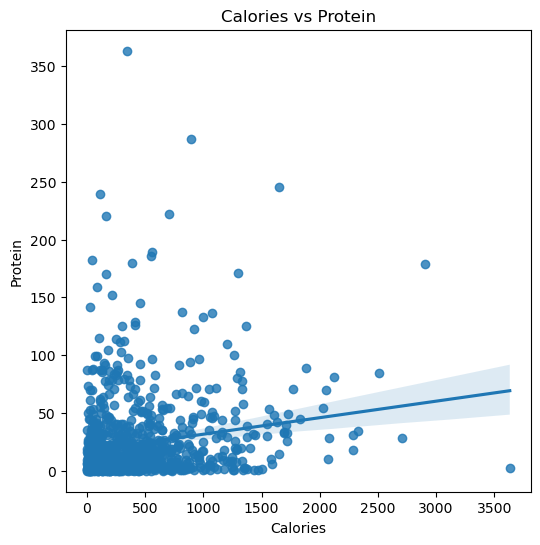

In [66]:
#with regression plot
plt.figure(figsize=(6,6))
sns.regplot(data=df, x='calories', y='protein')
plt.title("Calories vs Protein")
plt.xlabel("Calories")
plt.ylabel("Protein")
plt.show()